In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils.data_utils import CancerDataHelper
import warnings
from utils.evaluation_utils import EvaluationHelper
warnings.filterwarnings("ignore")

## Data Visualization

In [2]:
x_train, x_test, y_train, y_test = CancerDataHelper.load_dataset()
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

In [3]:
x_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
204,-0.454628,-0.169611,-0.432765,-0.486779,0.239073,0.020759,-0.110008,-0.267132,0.398003,0.106758,...,-0.256520,-0.183900,-0.324243,-0.351201,0.458375,-0.110609,-0.027633,-0.185340,0.164277,0.191312
70,1.403253,0.476556,1.335044,1.422857,-0.446475,-0.033542,0.237277,0.794111,-0.819161,-1.186798,...,1.799651,0.141212,1.757294,1.788040,-0.573944,-0.137733,-0.020013,0.991563,-0.571736,-1.015479
131,0.403960,0.040215,0.424317,0.299940,0.923904,0.329715,0.716890,0.829057,0.419294,-0.711643,...,0.635389,0.044014,0.535490,0.509645,0.990042,-0.100277,0.505717,0.573413,-0.117093,-0.216908
431,-0.474729,-0.388974,-0.416962,-0.528325,0.651406,0.503854,-0.142811,-0.529745,-0.006536,1.140753,...,-0.691039,-0.473819,-0.516155,-0.643071,0.564709,0.051487,-0.155256,-0.608053,-0.563788,0.531403
540,-0.721681,-1.161512,-0.700577,-0.719554,0.252698,0.136852,-0.267560,-0.582421,0.018304,0.686873,...,-0.819940,-1.015114,-0.838891,-0.747504,0.099500,-0.278518,-0.443836,-0.676781,-0.924641,-0.152688


In [4]:
y_train.head()

204    0
70     1
131    1
431    0
540    0
Name: diagnosis_M, dtype: int64

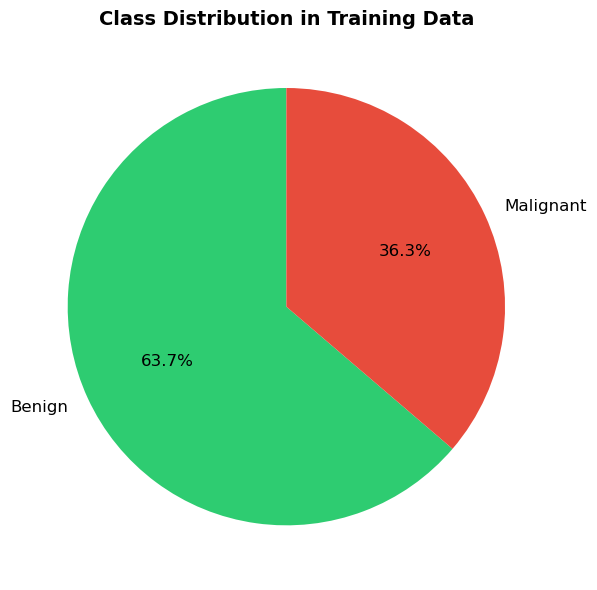

Benign: 290 (63.7%)
Malignant: 165 (36.3%)


In [5]:
CancerDataHelper.plot_outcome_distribution(x_train, y_train)

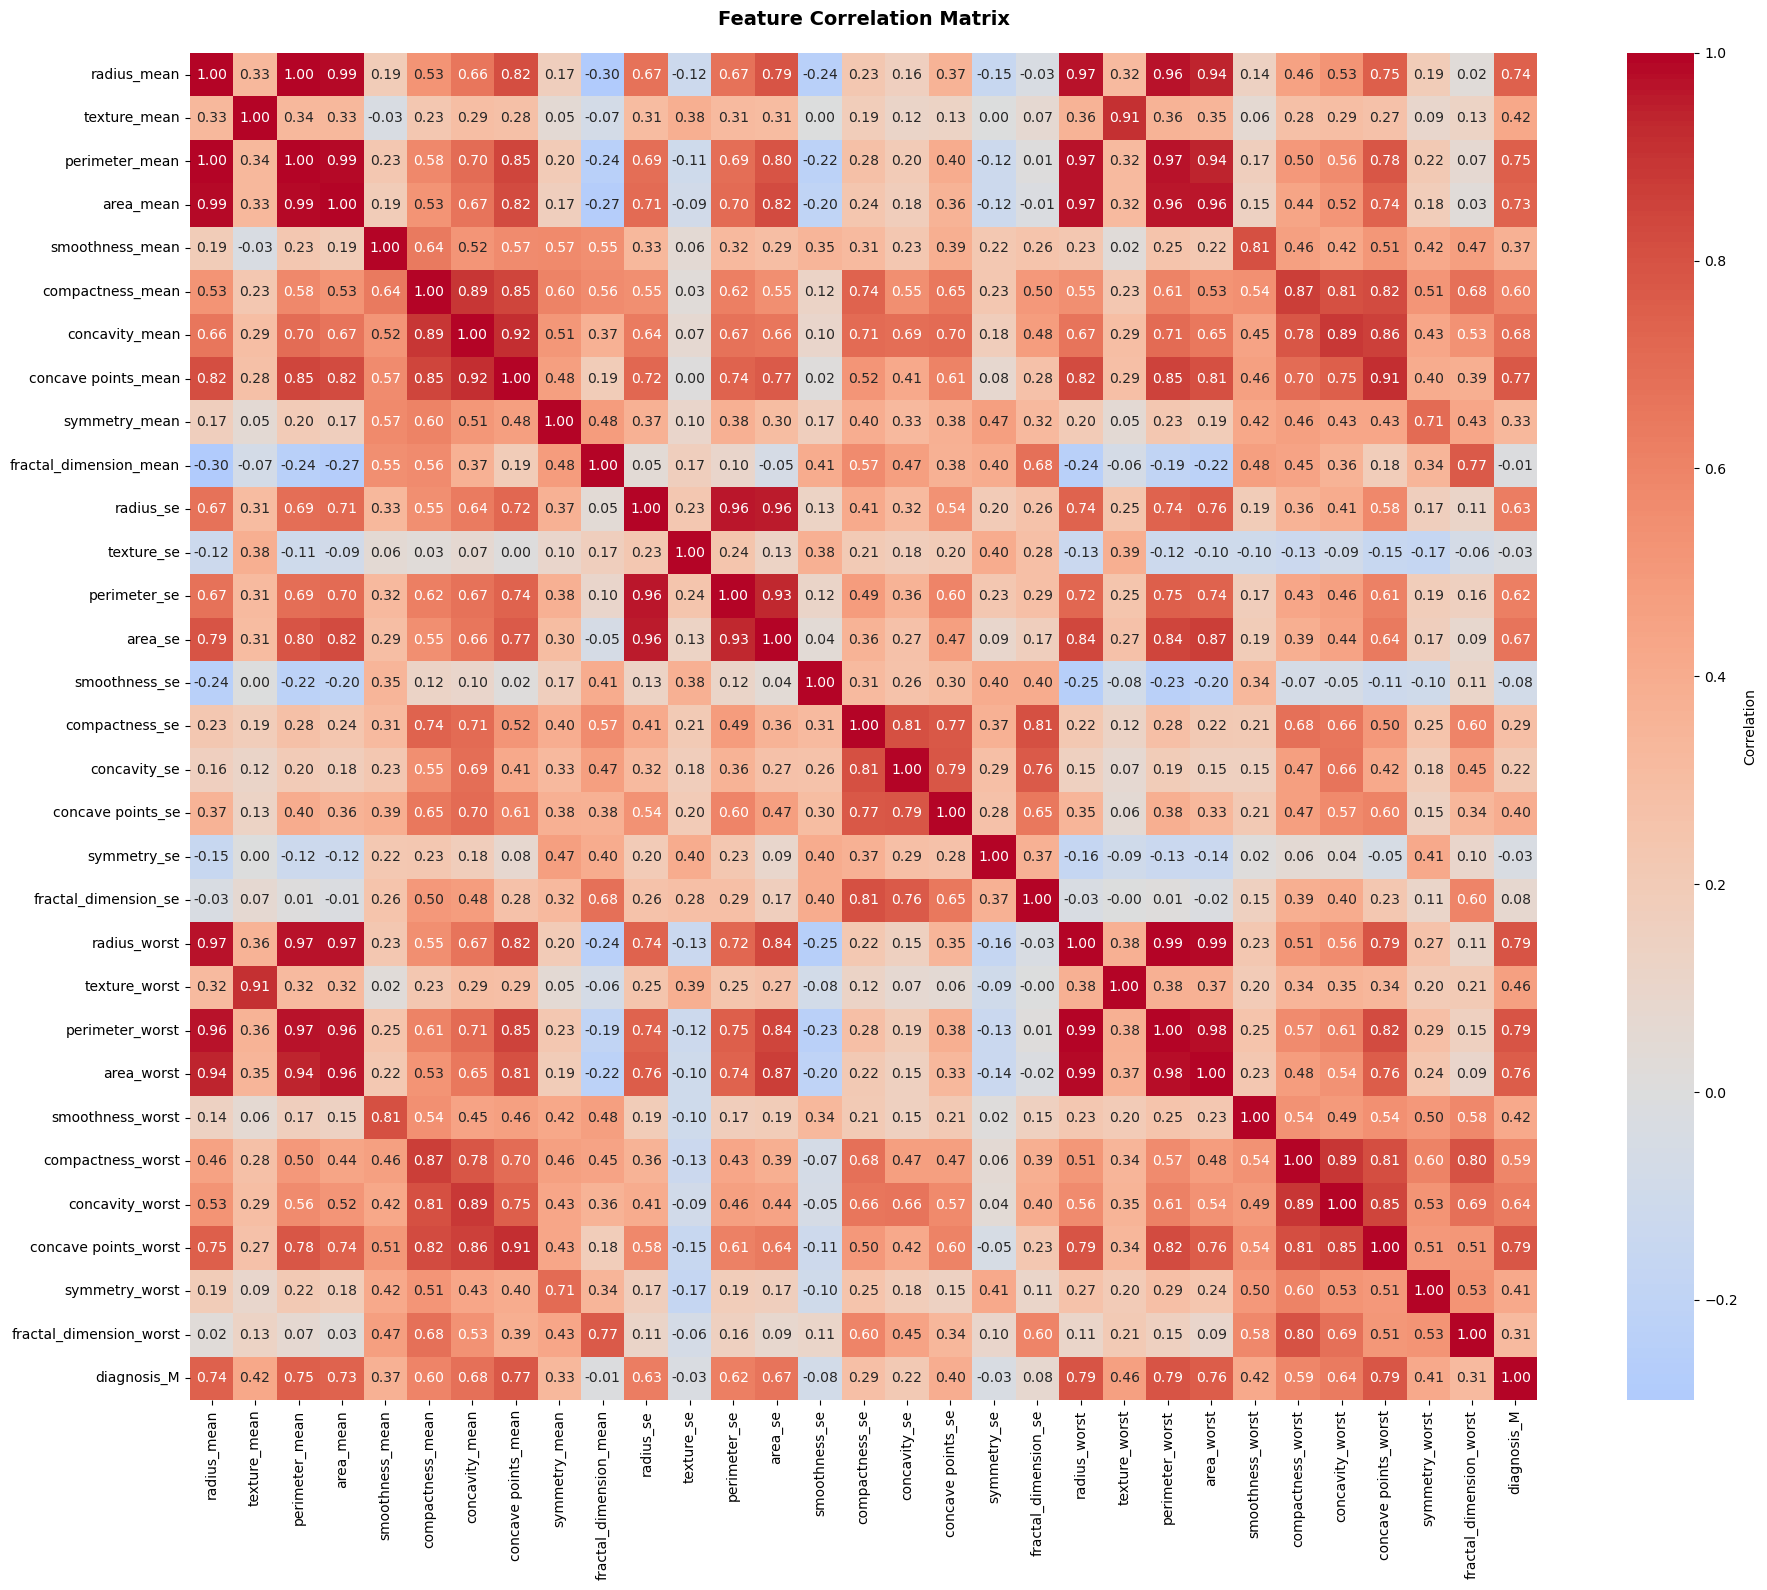

In [6]:
CancerDataHelper.plot_correlation(x_train, y_train)

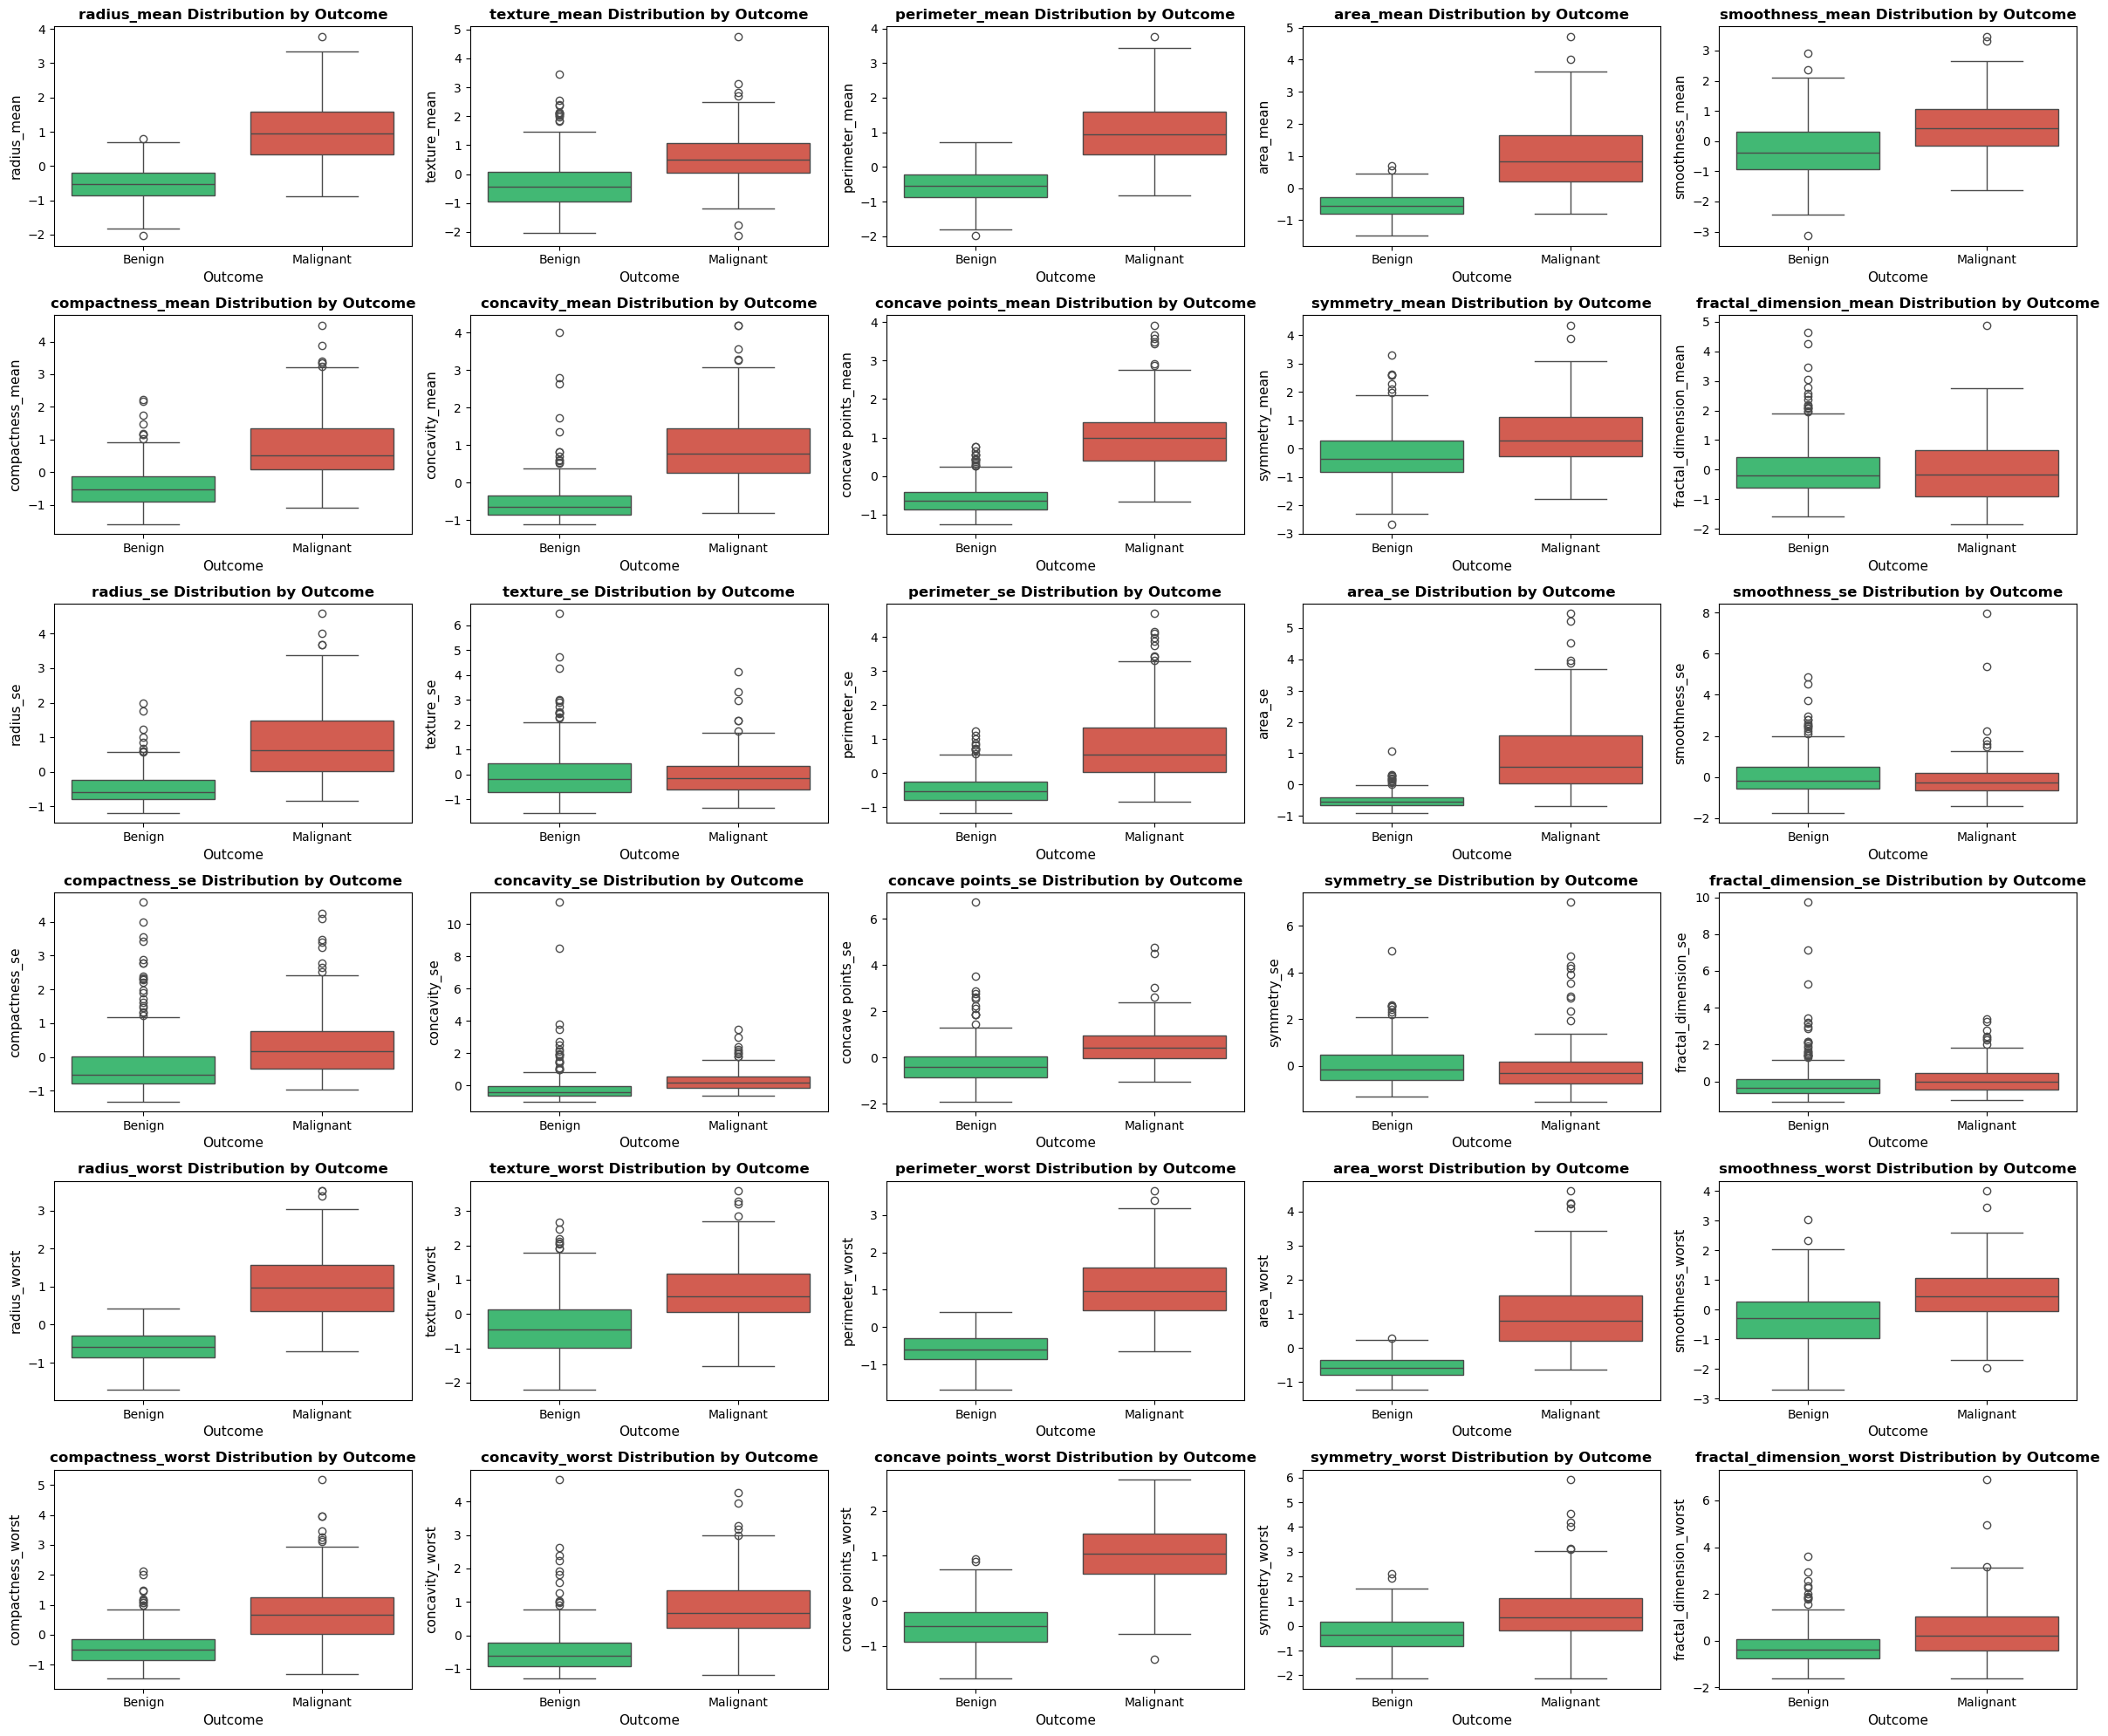

In [7]:
CancerDataHelper.plot_boxplots(x_train, y_train)

## Model Training

In [8]:
x_train = np.array(x_train)
x_test = np.array(x_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [9]:
n_features = x_train.shape[1]
weights = np.random.normal(0, np.sqrt(2.0 / n_features), size=(n_features))
bias = 0

weights.shape

(30,)

In [10]:
def sigmoid(linear):
    return 1 / (1 + np.exp(-linear))

In [11]:
def forward(x):
    linear = np.dot(x, weights) + bias
    return sigmoid(linear)

In [12]:
def compute_loss(y_true, prob):
    epsilon = 1e-15
    prob = np.clip(prob, epsilon, 1 - epsilon)
    loss = -(y_true * np.log(prob) + (1 - y_true) * np.log(1 - prob))
    return loss

In [13]:
def backward(x, prob, y_true, learning_rate=0.01):
    global weights, bias
    
    dw = x * (prob - y_true)
    db = prob - y_true
    
    weights -= dw * learning_rate
    bias -= db * learning_rate
    

In [14]:
epochs = 20_000
epoch_losses = []

learning_rate = 0.01

for epoch in range(epochs):
    total_loss = 0
    
    for idx in range(len(x_train)):
        prob = forward(x_train[idx])
        
        loss = compute_loss(y_train[idx], prob)
        total_loss += loss
        
        backward(x_train[idx], prob, y_train[idx], learning_rate)
    
    avg_loss = total_loss / len(x_train)
    
    if epoch > 0 and avg_loss >= epoch_losses[-1]:
        learning_rate *= 0.8

    epoch_losses.append(avg_loss)
    
    if (epoch + 1) % 1_000 == 0:
        print(f"Epoch: {epoch + 1}/{epochs} | Avg. Loss: {avg_loss}")

Epoch: 1000/20000 | Avg. Loss: 0.021325083346673906
Epoch: 2000/20000 | Avg. Loss: 0.016771937880766603
Epoch: 3000/20000 | Avg. Loss: 0.01458398412602928
Epoch: 4000/20000 | Avg. Loss: 0.013190508948045127
Epoch: 5000/20000 | Avg. Loss: 0.012175339802965748
Epoch: 6000/20000 | Avg. Loss: 0.011376745360963525
Epoch: 7000/20000 | Avg. Loss: 0.01071730943327066
Epoch: 8000/20000 | Avg. Loss: 0.010154686062343763
Epoch: 9000/20000 | Avg. Loss: 0.009663440189774854
Epoch: 10000/20000 | Avg. Loss: 0.009227189019640007
Epoch: 11000/20000 | Avg. Loss: 0.008834789130691863
Epoch: 12000/20000 | Avg. Loss: 0.008478320287366099
Epoch: 13000/20000 | Avg. Loss: 0.008151945069007021
Epoch: 14000/20000 | Avg. Loss: 0.007851227892400201
Epoch: 15000/20000 | Avg. Loss: 0.007572709728703937
Epoch: 16000/20000 | Avg. Loss: 0.007313632299378069
Epoch: 17000/20000 | Avg. Loss: 0.007071753345928561
Epoch: 18000/20000 | Avg. Loss: 0.006845219382956318
Epoch: 19000/20000 | Avg. Loss: 0.0066324758579115965
Epo

In [15]:
def predict(x):
    prob = forward(x)
    return prob >= 0.5, prob

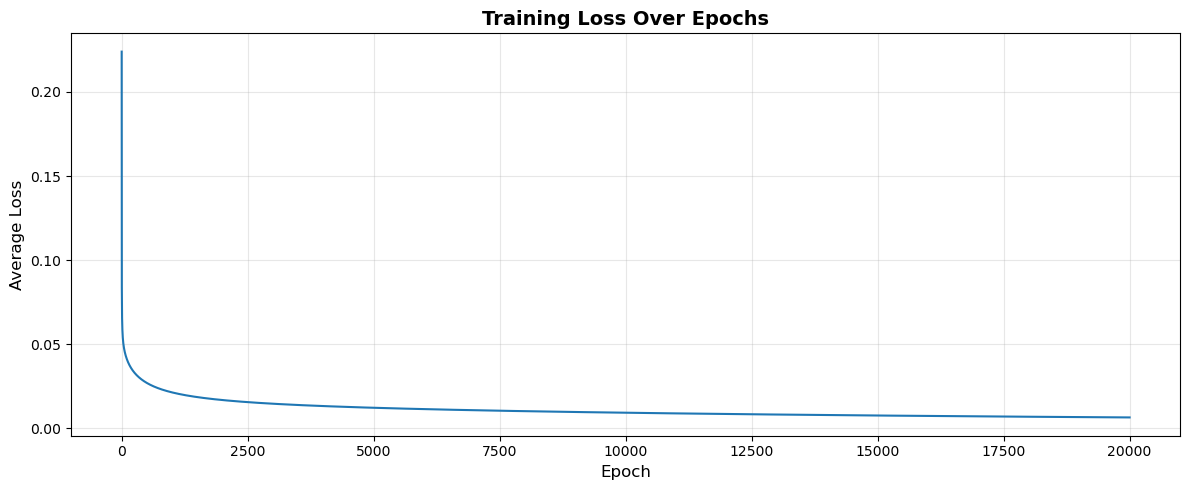

Initial loss: 0.223987
Final loss: 0.006432
Loss reduction: 97.13%


In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(epoch_losses, linewidth=1.5)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Average Loss", fontsize=12)
ax.set_title("Training Loss Over Epochs", fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial loss: {epoch_losses[0]:.6f}")
print(f"Final loss: {epoch_losses[-1]:.6f}")
print(f"Loss reduction: {(epoch_losses[0] - epoch_losses[-1])/epoch_losses[0]*100:.2f}%")

## Model Evaluation

In [17]:
predictions = []
probabilities = []

for x in x_test:
    prediction, prob = predict(x)
    predictions.append(prediction)
    probabilities.append(prob)

predictions = np.array(predictions)
probabilities = np.array(probabilities)

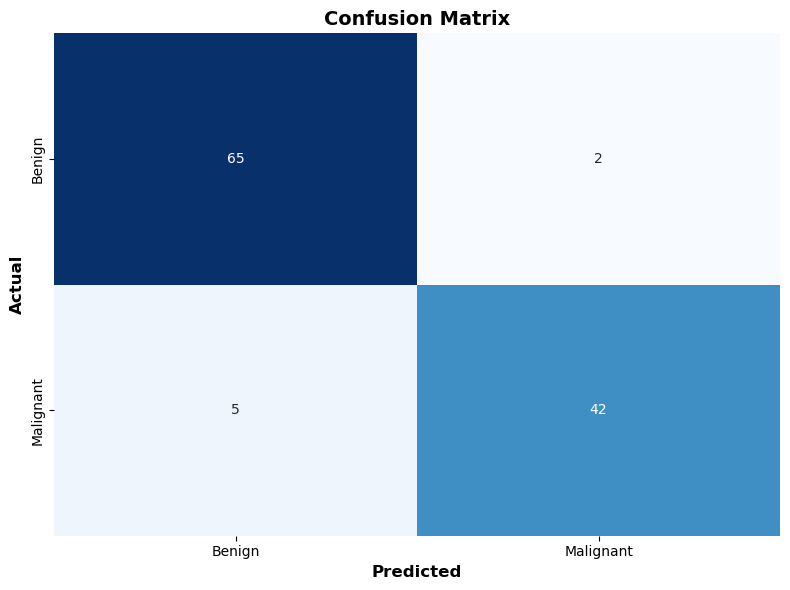

True Negatives: 65
False Positives: 2
False Negatives: 5
True Positives: 42

Sensitivity (Recall): 0.8936
Specificity: 0.9701
Precision: 0.9545
Accuracy: 0.9386
F1 Score: 0.9231


In [18]:
EvaluationHelper.plot_confusion_matrix(y_test, predictions, class_names=["Benign", "Malignant"])

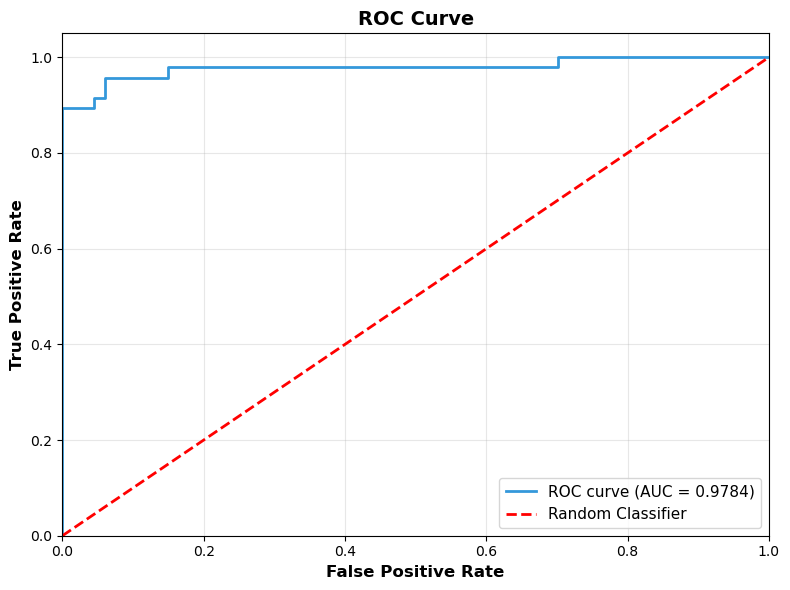

Area Under the Curve (AUC): 0.9784


In [19]:
EvaluationHelper.plot_roc_curve(y_test, probabilities)

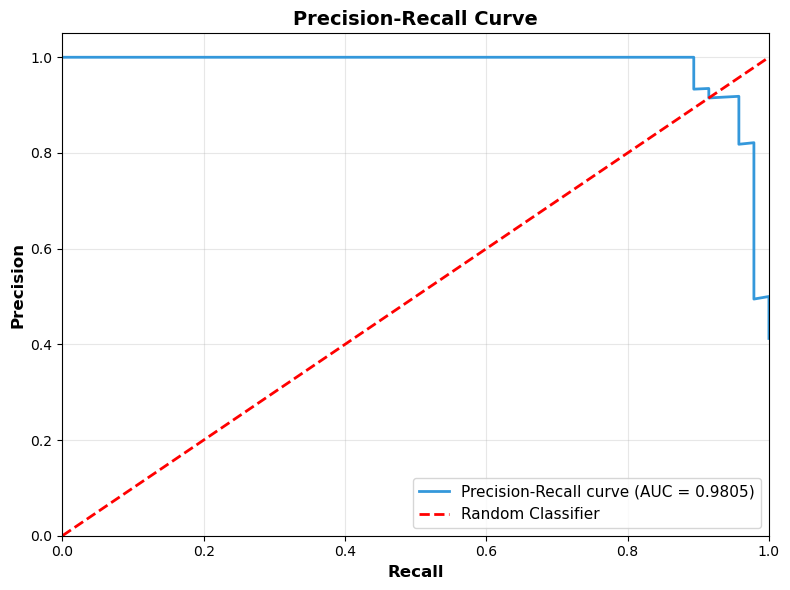

Area Under the Curve (AUC): 0.9805


In [20]:
EvaluationHelper.plot_precision_recall_curve(y_test, probabilities)